# World Cup 2026 Match Predictor

Rerun all cells to download the latest results, refit the model, and predict all upcoming fixtures.

## 1. Data

In [1]:
from data import load

training, upcoming = load()

print(f"Training matches: {len(training)}")
print(f"Date range: {training['date'].min():%Y-%m-%d} to {training['date'].max():%Y-%m-%d}")
print(f"Weight range: {training['weight'].min():.6f} to {training['weight'].max():.6f}")
print(f"Upcoming fixtures: {len(upcoming)}")
upcoming.head(10)

Training matches: 25428
Date range: 2000-01-04 to 2026-07-02
Weight range: 0.000102 to 0.998103
Upcoming fixtures: 6


,date,home_team,away_team,neutral,tournament,city,country
0,2026-07-04,Canada,Morocco,True,FIFA World Cup,Houston,United States
1,2026-07-04,Paraguay,France,True,FIFA World Cup,Philadelphia,United States
2,2026-07-05,Brazil,Norway,True,FIFA World Cup,East Rutherford,United States
3,2026-07-05,Mexico,England,False,FIFA World Cup,Mexico City,Mexico
4,2026-07-06,Portugal,Spain,True,FIFA World Cup,Dallas,United States
5,2026-07-06,United States,Belgium,False,FIFA World Cup,Seattle,United States


## 2. Model

In [2]:
from model import fit

model = fit(training)

print(f"Converged: {model.converged} | teams: {len(model.teams)} | "
      f"weighted log-likelihood: {model.log_likelihood:.1f}")
print(f"Home advantage: {model.home_adv:.3f} | Dixon-Coles rho: {model.rho:.3f}")
model.ratings().head(15)

Converged: True | teams: 321 | weighted log-likelihood: -3949.5
Home advantage: 0.233 | Dixon-Coles rho: -0.060


,team,attack,defense,strength
0,Argentina,1.205227,1.635788,2.841015
1,Spain,1.326983,1.335804,2.662787
2,Brazil,1.301864,1.186339,2.488203
3,England,1.084424,1.330768,2.415191
4,France,1.234246,1.178867,2.413112
5,Portugal,1.212819,1.159856,2.372675
6,Colombia,1.131963,1.162055,2.294018
7,Netherlands,1.210648,0.970737,2.181386
8,Morocco,0.805921,1.368560,2.174481
9,Germany,1.268099,0.877718,2.145816


## 3. Backtesting & Calibration

In [3]:
from data import download_results
from backtest import backtest_all

raw = download_results()
summary, records = backtest_all(raw)
summary

,tournament,n,log_loss,ll_uniform,ll_empirical,rps,rps_uniform,rps_empirical,score_hit,score_hit_modal,xg_mae,total_goals_bias
0,WC 2018,48,0.9225,1.0986,1.0656,0.1918,0.2465,0.2481,0.1458,0.0833,0.8171,-0.3294
1,WC 2022,48,1.0751,1.0986,1.0667,0.2288,0.2431,0.2414,0.1042,0.1250,0.9680,-0.2942
2,WC 2026,72,0.8446,1.0986,1.0871,0.1513,0.2315,0.2266,0.1250,0.1250,0.9323,-0.5359
3,pooled,168,0.9327,1.0986,1.0753,0.1850,0.2391,0.2368,0.1250,0.0893,0.9096,-0.4079


Reading the table: `log_loss` / `rps` are the model (lower is better); `ll_*` / `rps_*` columns are the naive baselines it must beat. `score_hit` is the exact-scoreline hit rate vs always guessing the historically most common score. Backtests use group-stage matches only — this dataset records knockout scores *including extra time*, which would mislabel 90-minute draws as wins. The weighting and regularization defaults behind these numbers were tuned by `tune.py` on 28 major-tournament editions 2006–2025 (WC 2026 held out); the model still under-predicts total goals by ~0.4/match, so don't lean on it for totals markets.

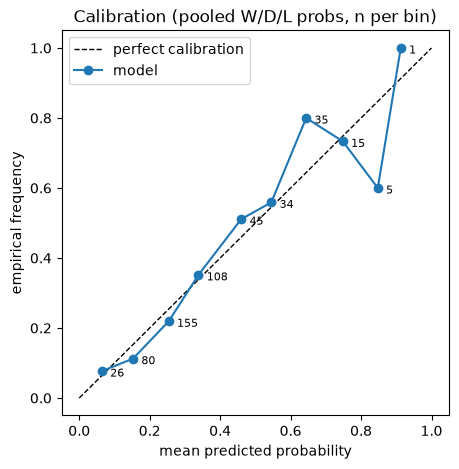

,bin,n,mean_predicted,empirical_rate
0,"[0.0, 0.1)",26,0.064376,0.076923
1,"[0.1, 0.2)",80,0.152805,0.112500
2,"[0.2, 0.3)",155,0.254132,0.219355
3,"[0.3, 0.4)",108,0.338490,0.351852
4,"[0.4, 0.5)",45,0.459927,0.511111
5,"[0.5, 0.6)",34,0.545163,0.558824
6,"[0.6, 0.7)",35,0.644219,0.800000
7,"[0.7, 0.8)",15,0.748274,0.733333
8,"[0.8, 0.9)",5,0.847526,0.600000
9,"[0.9, 1.0)",1,0.912705,1.000000


In [4]:
import matplotlib.pyplot as plt

from backtest import calibration_table, plot_calibration

plot_calibration(records)
plt.show()
calibration_table(records)

### Market comparison

The baselines above are table stakes — the benchmark that matters for betting is the bookmakers. `odds.py` downloads football-data.co.uk's World Cup workbook (1X2 odds for every 2018/2022/2026 match) and scores the de-vigged market-average probabilities on the same backtest matches. It also simulates flat 1-unit bets on every outcome where the raw model beats the market by ≥5 points, settled at market-average (`_avg`) and best-available (`_max`) prices.

Reading the result: the market still wins on log-loss and RPS pooled (the tuned model takes WC 2018, the market takes 2022 and 2026). Any positive P&L in the sim is longshot variance, not edge — flagged bets average odds of ~6, the pooled z is ~0.7, and a single shock result (South Korea over Germany 2018) accounts for most of the profit. Practical takeaway: an edge flagged by `check_odds` is more likely the model's blind spot than the market's mistake — which is what the recalibration and blend below are for.

In [5]:
from odds import compare_to_market

market_summary, market_merged = compare_to_market(records)
market_summary

,tournament,n,ll_model,ll_market,rps_model,rps_market,n_bets,pnl_avg,roi_avg,pnl_max,roi_max
0,WC 2018,48,0.9225,0.9312,0.1918,0.1960,47,20.02,0.426,29.70,0.632
1,WC 2022,48,1.0751,1.0318,0.2288,0.2228,37,3.49,0.094,5.28,0.143
2,WC 2026,72,0.8446,0.8195,0.1513,0.1433,55,-2.76,-0.050,0.97,0.018
3,pooled,168,0.9327,0.9121,0.1850,0.1810,139,20.75,0.149,35.95,0.259


### Recalibration & market blend

Two fixes layered on the raw model, each judged out-of-sample on the WC 2026 group stage (used for fitting neither layer):

1. **Recalibration** (`calibrate.py`): the calibration table above shows the raw model overstating longshots and understating favorites. Vector scaling (a temperature plus per-outcome offsets, fit on the group stages of 28 major-tournament editions 2006–2025) corrects the 1X2 probabilities.
2. **Market blend** (`odds.py`): a log-space blend of the calibrated model with the de-vigged market average, weight fit on WC 2018+2022 only. The weight says how much the model adds *on top of* the market; the ladder below says whether each layer earns its keep.

In [6]:
from odds import holdout_ladder

ladder, w_blend = holdout_ladder(market_merged)
print(f"blend weight on the model (fit on WC 2018+2022): {w_blend:.2f}")
ladder

blend weight on the model (fit on WC 2018+2022): 0.23


,probs,log_loss,rps
0,model (raw),0.8446,0.1513
1,model (calibrated),0.8412,0.1503
2,market (de-vigged avg),0.8195,0.1433
3,blend (w_model=0.23),0.8194,0.1434


## 4. Today's Predictions

In [7]:
from predict import predict, predict_fixtures

table = predict_fixtures(model, upcoming)
table

,date,match,xg_a,xg_b,score,score_prob,likeliest_by_outcome,p_win_a,p_draw,p_win_b,p_adv_a,p_adv_b
0,2026-07-04,Canada vs Morocco,0.61,1.07,0-0,0.194,W 1-0 (11%) | D 0-0 (19%) | L 0-1 (19%),0.200,0.344,0.456,0.351,0.649
1,2026-07-04,Paraguay vs France,0.64,1.56,0-1,0.165,W 1-0 (6%) | D 1-1 (12%) | L 0-1 (17%),0.146,0.266,0.589,0.249,0.751
2,2026-07-05,Brazil vs Norway,1.97,1.09,1-1,0.106,W 2-1 (10%) | D 1-1 (11%) | L 1-2 (5%),0.572,0.228,0.200,0.708,0.292
3,2026-07-05,Mexico vs England,0.88,1.27,0-1,0.140,W 1-0 (9%) | D 1-1 (14%) | L 0-1 (14%),0.250,0.304,0.446,0.387,0.613
4,2026-07-06,Portugal vs Spain,1.05,1.41,1-1,0.134,W 1-0 (8%) | D 1-1 (13%) | L 0-1 (11%),0.274,0.283,0.443,0.404,0.596
5,2026-07-06,United States vs Belgium,1.25,1.89,1-1,0.109,W 2-1 (6%) | D 1-1 (11%) | L 1-2 (10%),0.247,0.237,0.516,0.349,0.651


In [8]:
for f in upcoming.itertuples(index=False):
    p = predict(model, f.home_team, f.away_team, neutral=bool(f.neutral))
    print(p.summary())
    print()

Canada vs Morocco
  Expected goals:  Canada 0.61 — 1.07 Morocco
  Win/Draw/Win: 20.0% / 34.4% / 45.6%
  Likeliest score by outcome:
    Canada win  1-0 (10.6%)
    draw       0-0 (19.4%)
    Morocco win  0-1 (19.3%)
  Advances: Canada 35.1%, Morocco 64.9%

Paraguay vs France
  Expected goals:  Paraguay 0.64 — 1.56 France
  Win/Draw/Win: 14.6% / 26.6% / 58.9%
  Likeliest score by outcome:
    Paraguay win  1-0 (6.4%)
    draw       1-1 (11.8%)
    France win  0-1 (16.5%)
  Advances: Paraguay 24.9%, France 75.1%

Brazil vs Norway
  Expected goals:  Brazil 1.97 — 1.09 Norway
  Win/Draw/Win: 57.2% / 22.8% / 20.0%
  Likeliest score by outcome:
    Brazil win  2-1 (9.9%)
    draw       1-1 (10.6%)
    Norway win  1-2 (5.5%)
  Advances: Brazil 70.8%, Norway 29.2%

Mexico vs England (Mexico at home)
  Expected goals:  Mexico 0.88 — 1.27 England
  Win/Draw/Win: 25.0% / 30.4% / 44.6%
  Likeliest score by outcome:
    Mexico win  1-0 (9.5%)
    draw       1-1 (13.8%)
    England win  0-1 (14.0%)


### Odds check

Type in a bookmaker's decimal odds for the 1X2 (90-minute result) market. The table shows the pipeline from section 3: raw model → calibrated probabilities (`model_cal`) → blend with the de-vigged market at weight `w_blend`. A bet is flagged only when the **calibrated** model beats the market by at least `min_edge` (default 5 points) *and* the blend — the best available probability estimate — still gives positive EV at the offered odds.

Caveats: a *large* edge usually means the market knows team news the model can't see — check that first. The market comparison above backs this up on 168 matches: the de-vigged market average out-predicted the raw model in all three tournaments, so treat flagged edges as hypotheses against you, not free money. Penalties are modeled as a coin flip, so be skeptical of "to qualify" prices. And never bet unders off this model: the backtests measured it under-predicting total goals.

In [9]:
import numpy as np
import pandas as pd

from calibrate import TUNED, apply_calibration
from odds import blend


def check_odds(team_a, team_b, odds_win, odds_draw, odds_loss,
               neutral=True, knockout=True, min_edge=0.05):
    """Show the model's full prediction for a match, then compare bookmaker
    1X2 decimal odds against the calibrated model and the market blend."""
    p = predict(model, team_a, team_b, neutral=neutral, knockout=knockout)

    print(p.summary())
    print()

    outcomes = [f"{team_a} win", "draw", f"{team_b} win"]
    odds = np.array([odds_win, odds_draw, odds_loss], dtype=float)

    implied = 1.0 / odds
    overround = implied.sum()
    market = implied / overround

    raw = np.array([p.p_win_a, p.p_draw, p.p_win_b])
    cal = apply_calibration(raw, TUNED)[0]
    mix = blend(cal[None, :], market[None, :], w_blend)[0]

    table = pd.DataFrame({
        "outcome": outcomes,
        "odds": odds,
        "market_prob": market.round(3),
        "model_raw": raw.round(3),
        "model_cal": cal.round(3),
        "blend_prob": mix.round(3),
        "edge_cal": (cal - market).round(3),
        "ev_blend_$1": (mix * odds - 1).round(3),
    })
    print(f"Bookmaker margin {overround - 1:.1%}, min edge to act {min_edge:.0%}")
    print(table.to_string(index=False))

    flagged = table[(table["edge_cal"] >= min_edge) & (table["ev_blend_$1"] > 0)]
    if flagged.empty:
        print("\nVerdict: NO BET — no outcome clears both the edge threshold "
              "and positive blend EV.")
    else:
        for _, r in flagged.iterrows():
            print(f"\nVerdict: value on {r['outcome']!r} "
                  f"(calibrated edge {r['edge_cal']:+.1%}, "
                  f"blend EV {r['ev_blend_$1']:+.1%} per $1)."
                  f"\n  Before acting: check team news — a gap this size is "
                  f"often the market pricing in something the model can't see.")
    return table


# Example — replace with a real fixture and the odds you see:
check_odds("Morocco", "Canada", odds_win=1.72, odds_draw=3.30, odds_loss=4.30, neutral=True, knockout=True, min_edge=0.05);

Morocco vs Canada
  Expected goals:  Morocco 1.07 — 0.61 Canada
  Win/Draw/Win: 45.6% / 34.4% / 20.0%
  Likeliest score by outcome:
    Morocco win  1-0 (19.3%)
    draw       0-0 (19.4%)
    Canada win  0-1 (10.6%)
  Advances: Morocco 64.9%, Canada 35.1%

Bookmaker margin 11.7%, min edge to act 5%
    outcome  odds  market_prob  model_raw  model_cal  blend_prob  edge_cal  ev_blend_$1
Morocco win  1.72        0.521      0.456      0.459       0.507    -0.062       -0.129
       draw  3.30        0.271      0.344      0.345       0.288     0.074       -0.051
 Canada win  4.30        0.208      0.200      0.196       0.206    -0.012       -0.115

Verdict: NO BET — no outcome clears both the edge threshold and positive blend EV.
